<a href="https://colab.research.google.com/github/hieuvu-0111/Machine_Learning_Logistic_Regression/blob/main/Machine_Learning_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression - Heart Disease dataset {-}

This notebook is adapted from a Machine Learning course assignment aiming at familiarize students with the use of Logistic Regression model supported by scikit-learn. Tasks include:

1.  **Coding Tasks:**

    1.1 Analyze the dataset using libraries like Pandas and atplotlib.  
    1.2 Preprocess the data to prepare for modeling.  
    1.3 Divide the data into training and test sets with a suitable ratio (e.g., 80/20) to ensure unbiased model evaluation.  
    1.4 Train a Logistic Regression model on the training set.    
    1.5 Evaluate the model performance on the test set using the following metrics: precision, recall, f1 score, and print out the confusion matrix.  

2.  **Open discussion questions:**

    2.1 Is there a relationship between age and the likelihood of heart disease in this dataset? Can you explore this for different age groups?  
    2.2 How do vital signs like blood pressure and cholesterol levels compare between patients with and without heart disease?  
    2.3 Does having high fasting blood sugar appear to be a risk factor for heart disease according to this dataset?  
    2.4 Considering all the features, what features do you think might be the most important in predicting heart disease based on this dataset?  

The dataset we will be working on is 'heart-disease.csv'. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, etc. This dataset is to predict, based on the given attributes of a patient, whether that particular person has a heart disease or not.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('heart-disease.csv')

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
1,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
2,71,0,1,160,303,0,1,163,0,0.4,2,2,2,1
3,71,0,1,160,304,0,1,164,0,0.4,2,2,2,1
4,71,0,1,160,305,0,1,165,0,0.4,2,2,2,1


### Data features: {-}

* age: The person’s age in years
* sex: The person’s sex (1 = male, 0 = female)
* cp: chest pain type
  * Value 0: asymptomatic
  * Value 1: atypical angina
  * Value 2: non-anginal pain
  * Value 3: typical angina
* trestbps: The person’s resting blood pressure (mm Hg on admission to the hospital)
* chol: The person’s cholesterol measurement in mg/dl (mg/dl: milligrams per decilitre)
* fbs: The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false) (Fasting blood glucose: A test to determine how much glucose (sugar) is in a blood sample after an overnight without eating).
* restecg: resting electrocardiographic results
  * Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
  * Value 1: normal
  * Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
* thalach: The person’s maximum heart rate achieved
* exang: Exercise induced angina (1 = yes; 0 = no)
* oldpeak: ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot)
* slope: the slope of the peak exercise ST segment
  * 0: downsloping
  * 1: flat
  * 2: upsloping
* ca: The number of major vessels (values in 0–3)
* thal: A blood disorder called thalassemia
  * Value 0: NULL (dropped from the dataset previously
  * Value 1: fixed defect (no blood flow in some part of the heart)
  * Value 2: normal blood flow
  * Value 3: reversible defect (a blood flow is observed but it is not normal)
  
### Data label: {-}

* target: Heart disease (1 = no, 0= yes)

# Solution

## 3.1.1. Coding tasks

### 3.1.1.1 (1 point) Analyze the dataset using libraries like Pandas and Matplotlib.

In [ ]:
df.info()          # Show dataset info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       886 non-null    int64  
 1   sex       886 non-null    int64  
 2   cp        886 non-null    int64  
 3   trestbps  886 non-null    int64  
 4   chol      886 non-null    int64  
 5   fbs       886 non-null    int64  
 6   restecg   886 non-null    int64  
 7   thalach   886 non-null    int64  
 8   exang     886 non-null    int64  
 9   oldpeak   886 non-null    float64
 10  slope     886 non-null    int64  
 11  ca        886 non-null    int64  
 12  thal      886 non-null    int64  
 13  target    886 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 97.0 KB


This dataset contains 13 data features and a data labeled named 'target'. All of them are numerical, with only feature named 'oldpeak' being in float type while the rest are integers. All of the counted non-null data features and label are 886, so this dataset does not appear to include any NA values.

In [ ]:
# descriptive statistics
print("Statistics of numerical values \n")
print(df.describe())

Statistics of numerical values 

              age         sex          cp    trestbps        chol         fbs  \
count  886.000000  886.000000  886.000000  886.000000  886.000000  886.000000   
mean    54.007901    0.683973    1.005643  132.117381  247.497743    0.168172   
std      9.126292    0.465186    1.024542   16.807511   47.209995    0.374230   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.000000    0.000000    0.000000  120.000000  212.000000    0.000000   
50%     54.000000    1.000000    1.000000  130.000000  245.000000    0.000000   
75%     60.000000    1.000000    2.000000  140.000000  274.000000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  886.000000  886.000000  886.000000  886.000000  886.000000  886.000000   
mean     0.495485  149.492099    0.310384    1.083296    1.424379    0.7144

It seems this is a good dataset, as the range of data features are reasonable. It does not contain any values that exceed the limited range.

Continuous Columns
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')



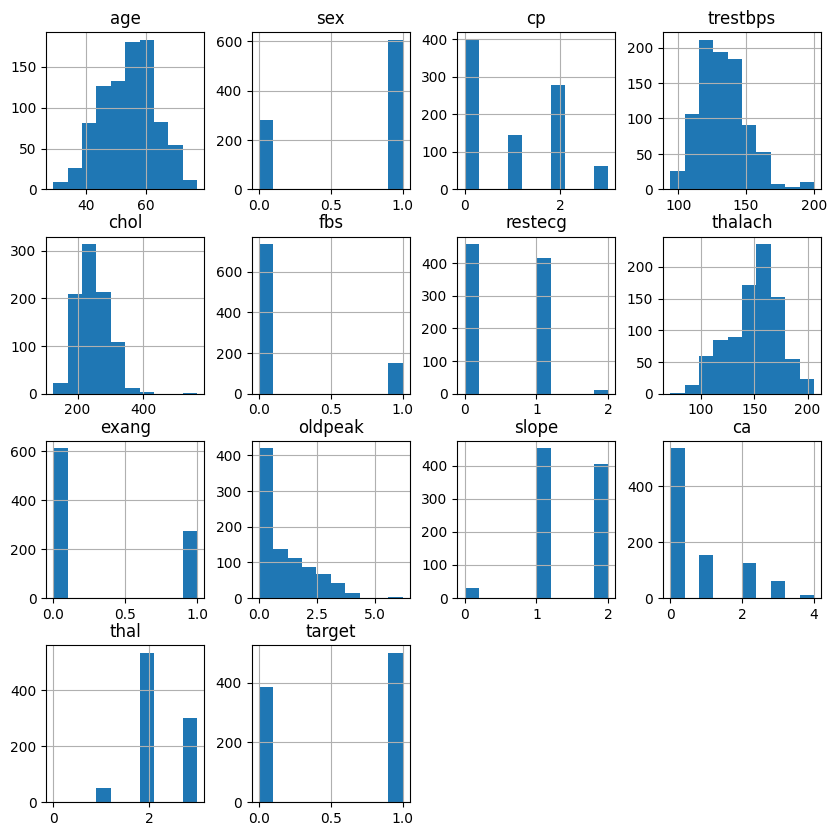

In [ ]:
# Visualization
print("Continuous Columns")
continuous_columns = df.describe().columns
print(continuous_columns)
df.hist(column=continuous_columns, figsize=(10, 10))          # plot histogram of all columns, by default bin=10
print()


The data features appear to follow a normal distribution overall. For continuous variables such as age, resting blood pressure, cholesterol levels, and heart rate, the plots exhibit bell-shaped curves consistent with normality. Also, numerically enconed features like sex and chest pain type show no significant outliers or irregularities in their distributions.

### 3.1.1.2 (0.5 point) Preprocess the data to prepare for modeling.

In [ ]:
data = df.copy()
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
1,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
2,71,0,1,160,303,0,1,163,0,0.4,2,2,2,1
3,71,0,1,160,304,0,1,164,0,0.4,2,2,2,1
4,71,0,1,160,305,0,1,165,0,0.4,2,2,2,1


In [ ]:
# Generate label y
y = data['target'].values                                        # Initialize label y as a 1D numpy array
print("Before reshaping: " + str(y.shape))           # One-dimensional array
print("After reshaping: " + str(y.shape)) # Shape will be the same as 'Before reshaping'

# Generate feature X from data frame
X = data.drop('target', axis=1, inplace=False).values     # Drop column 'y' in data frame, note: axis{0 or ‘index’, 1 or ‘columns’}, default 0. Then convert to array values.

Before reshaping: (886,)
After reshaping: (886,)


### 3.1.1.3 (0.5 point) Divide the data into training and test sets with a suitable ratio (e.g., 80/20) to ensure unbiased model evaluation.

In [ ]:
# Split the dataset to training and testing, ratio 80:20.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)         # Train-test split with fixed random state

print("X_train: " + str(X_train.shape))
print("y_train: " + str(y_train.shape))
print("X_test: " + str(X_test.shape))
print("y_test: " + str(y_test.shape))

X_train: (708, 13)
y_train: (708,)
X_test: (178, 13)
y_test: (178,)


In [ ]:
#Scale dataset
from sklearn.preprocessing import StandardScaler     # Import function to perform Standardization
scaler = StandardScaler()                            # Initialize the StandardScaler
X_train_scaler = scaler.fit_transform(X_train)       # Fit (compute mean and std), then transform training data using these values.
X_test_scaler = scaler.transform(X_test)             # ONLY transform test data, using mean and std of training data

### 3.1.1.4 (0.5 point) Train a Logistic Regression model on the training set.

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression()                      # Initialize Logistic Regression model
logmodel.fit(X_train_scaler, y_train.ravel())                # Train the model

LogisticRegression()

### 3.1.1.5 (0.5 point) Evaluate the model performance on the test set using the following metrics: precision, recall, f1 score, and print out the confusion matrix.

In [ ]:
# Calculate prediction labels
predictions = logmodel.predict(X_test_scaler)                # Predict labels for X_test_scaler
final_prediction = pd.DataFrame({'target':predictions})      # Import labels to a dataframe
print(final_prediction)

     target
0         1
1         0
2         0
3         1
4         0
..      ...
173       1
174       1
175       1
176       0
177       0

[178 rows x 1 columns]


In [ ]:
# Evaluation metrics calculation
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Precision: ", precision_score(logmodel.predict(X_test_scaler), y_test))
print("Recall: ", recall_score(logmodel.predict(X_test_scaler), y_test))
print("F1: ", f1_score(logmodel.predict(X_test_scaler), y_test))
print("Confusion matrix: \n", confusion_matrix(logmodel.predict(X_test_scaler), y_test))
print("Classification report: \n", classification_report(logmodel.predict(X_test_scaler), y_test))

Precision:  0.94
Recall:  0.9591836734693877
F1:  0.9494949494949495
Confusion matrix: 
 [[74  6]
 [ 4 94]]
Classification report: 
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        80
           1       0.94      0.96      0.95        98

    accuracy                           0.94       178
   macro avg       0.94      0.94      0.94       178
weighted avg       0.94      0.94      0.94       178



From the confusion matrix and classification report, we can derive some following insights:

- Precision (0.94): When the model predicts a patient has heart disease, it is correct 94% of the time. It means that the prediction has low risk of unnecessary alarm or overtreatment. This is a good and effective result.

- Recall (0.959): The model detects about 96% of actual heart disease cases, i.e., very few patients with heart disease are missed, which is critical because missing a positive case can lead to severe consequences. This index also shows that this model predicts effectively.

- F1-score (0.949): The index indicates a balanced measure of precision and recall, showing the model is strong in both detecting disease and avoiding false alarms.

- Accuracy (94%): The model correctly predicts heart disease presence or absence in 94% of cases. This is strong overall performance, but accuracy alone is not enough in healthcare because false negatives can be dangerous.

- Confusion Matrix:
  - False Negatives: Only 4 patients with heart disease were predicted as healthy.
  - False Positives: 6 healthy patients were predicted as having heart disease.
- Class 1 (heart disease) has slightly better recall (0.96) than Class 0 (healthy), which is desirable because missing a disease case is more harmful than a false alarm.

Overall, it appears that the model prioritizes catching true cases, i.e., high recall, which is appropriate for medical diagnostic. But it should be noted that other indexes are also high, thus the model shows an overall good performance.



## 3.1.2. Open discussion questions

### 3.1.2.1 (1 point) Is there a relationship between age and the likelihood of heart disease in this dataset? Can you explore this for different age groups?

Heart disease incidence by age:
target  0   1  proportion_disease
age                              
29      0   9                 0.0
34      0  18                 0.0
35      2   2                 0.5
37      0   2                 0.0
38      1   1                 0.5

Heart disease incidence by age group:
target       0    1  Total  Percentage_Disease
age_group                                     
20-29        0    9      9            0.000000
30-39       12   26     38           31.578947
40-49       70  138    208           33.653846
50-59      156  241    397           39.294710
60-69      128   64    192           66.666667
70-79       20   22     42           47.619048


/tmp/ipython-input-3421790851.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_disease_counts = df.groupby(['age_group', 'target']).size().unstack(fill_value=0)


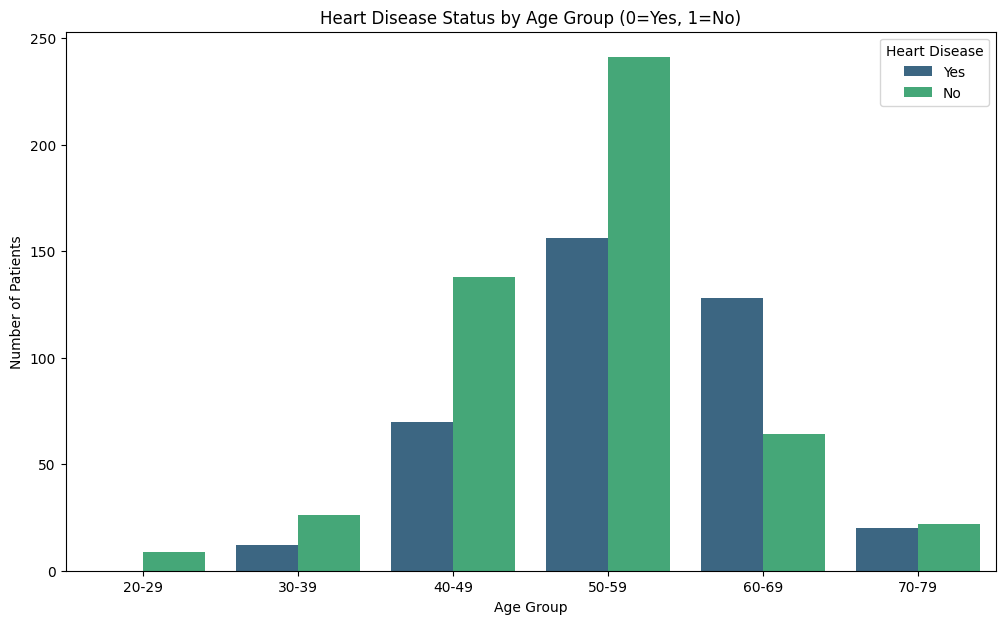

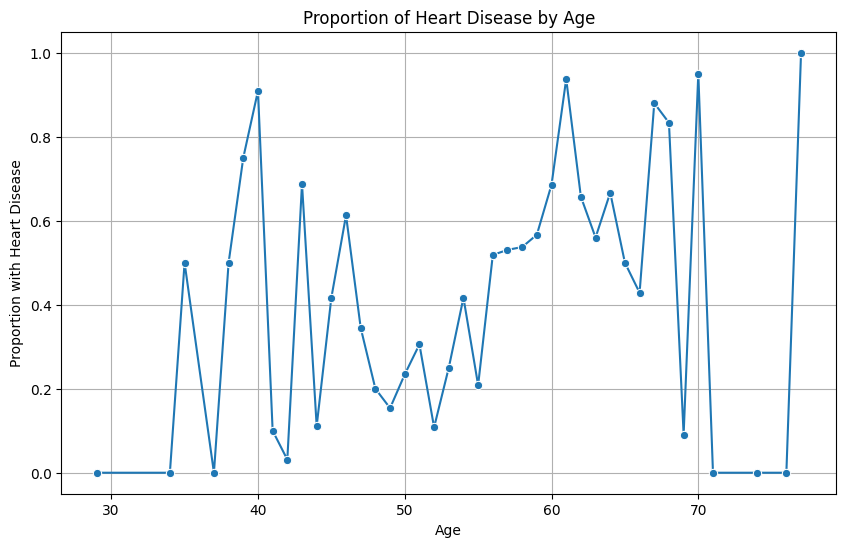

In [ ]:
# Heart disease vs age
print("Heart disease incidence by age:")
heart_disease_by_age = df.groupby(['age', 'target']).size().unstack(fill_value=0)

# Calculate the proportion of heart disease (target=0) for each age
heart_disease_by_age['proportion_disease'] = heart_disease_by_age[0] / (heart_disease_by_age[0] + heart_disease_by_age[1])
print(heart_disease_by_age.head())

# Explore for different age groups
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20-29', '30-39', '40-49', '50-59', '60-69', '70-79'], right=False)
age_group_disease_counts = df.groupby(['age_group', 'target']).size().unstack(fill_value=0)

# Calculate the percentage of heart disease within each age group
age_group_disease_counts['Total'] = age_group_disease_counts.sum(axis=1)
age_group_disease_counts['Percentage_Disease'] = (age_group_disease_counts[0] / age_group_disease_counts['Total']) * 100
print("\nHeart disease incidence by age group:")
print(age_group_disease_counts)

# Visualize using seaborn
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='age_group', hue='target', palette='viridis')
plt.title('Heart Disease Status by Age Group (0=Yes, 1=No)')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['Yes', 'No'])
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=heart_disease_by_age.reset_index(), x='age', y='proportion_disease', marker='o')
plt.title('Proportion of Heart Disease by Age')
plt.xlabel('Age')
plt.ylabel('Proportion with Heart Disease')
plt.grid(True)
plt.show()

In [ ]:
# Double check the result for specific age group to see bias in dataset
print("Heart disease incidence by age (around 40):")
display(heart_disease_by_age.loc[39:42])

print("\nHeart disease incidence by age (around 70-75):")
display(heart_disease_by_age.loc[70:75])

Heart disease incidence by age (around 40):


target,0,1,proportion_disease
age,,,
39,9,3,0.750000
40,10,1,0.909091
41,1,9,0.100000
42,1,31,0.031250



Heart disease incidence by age (around 70-75):


target,0,1,proportion_disease
age,,,
70,19,1,0.95
71,0,11,0.00
74,0,1,0.00


Based on the analysis of the dataset, there is an observable relationship between a patient's age and their likelihood of having heart disease. Generally, we can say that the incidence of heart disease increases with age. This is also a common finding in medical research.

From the table of different age group and the bar plot, it turns out that younger age groups (e.g., 20-29, 30-39) show a relatively low percentage of individuals with heart disease. The likelihood of heart disease steadily increases as we move into middle and older age groups. The '60-69' age group, in particular, shows a significantly higher percentage of heart disease (66.67%) compared to other groups, suggesting this is a critical period where the risk becomes substantially elevated. Then, the '70-79' age group shows a slightly lower percentage (47.62%) than the '60-69' group. This might be due to various factors such as smaller sample size at extreme ages, or survivorship bias where individuals with more severe heart disease might not reach these older age brackets.

With the individual age proportions shown in the line plot, while the overall trend shows an increase, the line plot for individual ages appears more fluctuated, with sharp peaks and drops (e.g., around age 40, and the extreme fluctuations between 70-75). These fluctuations are due to small sample sizes at specific individual ages. Indeed, when only a few patients are present for a given age, the proportion of heart disease can swing dramatically with minor changes in the number of positive cases. For example, from the double-checked table, we see that the drop to 0% at age 71 or 74 was due to very few individuals (11 and 1 respectively) at those ages, none of whom happened to have heart disease in this particular dataset slice.

### 3.1.2.2 (1 point) How do vital signs like blood pressure and cholesterol levels compare between patients with and without heart disease?

Comparison of vital signs between patients with and without heart disease:
                      trestbps        chol
target                                    
Heart Disease: Yes  135.841969  252.502591
Heart Disease: No   129.242000  243.634000


/tmp/ipython-input-1910712752.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='trestbps', palette='viridis')
/tmp/ipython-input-1910712752.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='chol', palette='viridis')


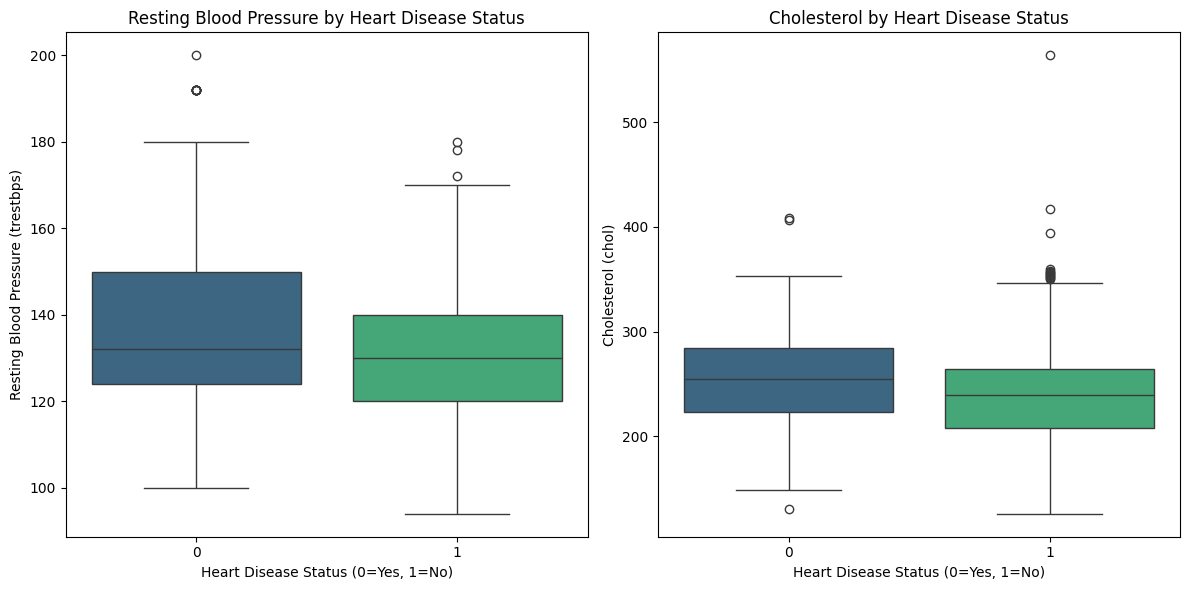

In [ ]:
# Compare vital signs vs heart diseases
print("Comparison of vital signs between patients with and without heart disease:")
vital_signs_comparison = df.groupby('target')[['trestbps', 'chol']].mean().rename(index={0: 'Heart Disease: Yes', 1: 'Heart Disease: No'})
print(vital_signs_comparison)

# Visualize using boxplots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='target', y='trestbps', palette='viridis')
plt.title('Resting Blood Pressure by Heart Disease Status')
plt.xlabel('Heart Disease Status (0=Yes, 1=No)')
plt.ylabel('Resting Blood Pressure (trestbps)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='target', y='chol', palette='viridis')
plt.title('Cholesterol by Heart Disease Status')
plt.xlabel('Heart Disease Status (0=Yes, 1=No)')
plt.ylabel('Cholesterol (chol)')

plt.tight_layout()
plt.show()

Based on the analysis of resting blood pressure (`trestbps`) and cholesterol (`chol`) levels, there are observable differences between patients with and without heart disease in this dataset.

First, from the `vital_signs_comparison` table, patients with heart disease (target=0) have an average resting blood pressure of approximately **135.84 mm Hg**, which is higher than patients without heart disease (target=1), who have an average of about **129.24 mm Hg**. Similarly, patients with heart disease have a higher average cholesterol level of approximately **252.50 mg/dl**, compared to those without heart disease, whose average is about **243.63 mg/dl**.

The visualizationt then confirms the patterns in table. The distribution for patients with heart disease (target=0) is shifted upwards compared to those without heart disease (target=1). The median blood pressure for the heart disease group is noticeably higher, and their overall range of values also tends to be high. Also, patients with heart disease (target=0) tend to have a higher median cholesterol level, and their interquartile range is generally positioned at higher values compared to the group without heart disease (target=1).

Therefore, according to this dataset, patients with heart disease generally exhibit higher resting blood pressure and higher cholesterol levels than those without heart disease, as seen in both the numerical and the visual distributions above.

### 3.1.2.3 (1 point) Does having high fasting blood sugar appear to be a risk factor for heart disease according to this dataset?

Fasting Blood Sugar (fbs) and Heart Disease:
target            Heart Disease: Yes  Heart Disease: No
fbs                                                    
FBS <= 120 mg/dl                 324                413
FBS > 120 mg/dl                   62                 87

Percentage of Heart Disease by Fasting Blood Sugar Status:
target            Heart Disease: Yes (%)  Heart Disease: No (%)
fbs                                                            
FBS <= 120 mg/dl               43.962008              56.037992
FBS > 120 mg/dl                41.610738              58.389262


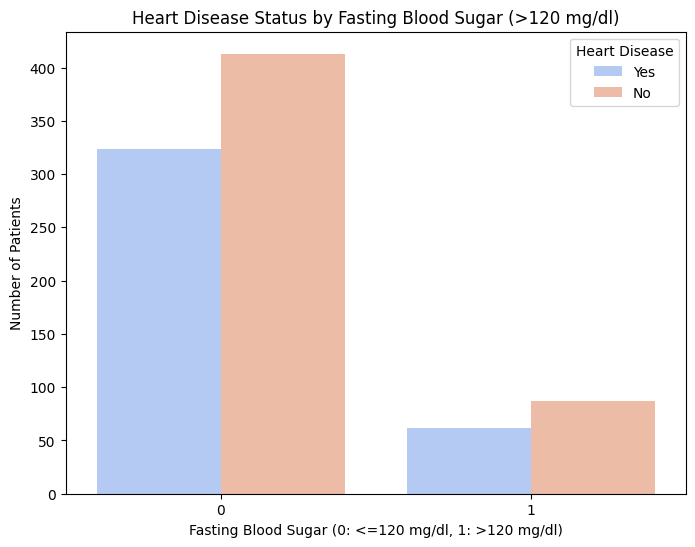

In [ ]:
# fbs vs heart disease
print("Fasting Blood Sugar (fbs) and Heart Disease:")
fbs_disease_counts = df.groupby(['fbs', 'target']).size().unstack(fill_value=0)
print(fbs_disease_counts.rename(index={0: 'FBS <= 120 mg/dl', 1: 'FBS > 120 mg/dl'}, columns={0: 'Heart Disease: Yes', 1: 'Heart Disease: No'}))

# Calculate percentages for better comparison
fbs_disease_percentages = fbs_disease_counts.apply(lambda x: x / x.sum() * 100, axis=1)
print("\nPercentage of Heart Disease by Fasting Blood Sugar Status:")
print(fbs_disease_percentages.rename(index={0: 'FBS <= 120 mg/dl', 1: 'FBS > 120 mg/dl'}, columns={0: 'Heart Disease: Yes (%)', 1: 'Heart Disease: No (%)'}))

# Visualize using a countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='fbs', hue='target', palette='coolwarm')
plt.title('Heart Disease Status by Fasting Blood Sugar (>120 mg/dl)')
plt.xlabel('Fasting Blood Sugar (0: <=120 mg/dl, 1: >120 mg/dl)')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease', labels=['Yes', 'No'])
plt.show()

From the table above, we can see that, for patients with normal fasting blood sugar (FBS <= 120 mg/dl), 324 of them had heart disease ('Heart Disease: Yes'), and 413 did not ('Heart Disease: No'); whereas, for patients with high fasting blood sugar (FBS > 120 mg/dl), 62 had heart disease, and 87 did not. In percentages, among those with normal FBS, approximately 43.96% had heart disease, while among those with high FBS, approximately 41.61% had heart disease. The countplot also visually represents these numbers. While there are fewer patients overall in the 'high FBS' group, the proportion of 'Heart Disease: Yes' versus 'Heart Disease: No' within that group appears quite similar to the 'normal FBS' group.

Therefore, according to this dataset, it does not appear that having high fasting blood sugar is a significant risk factor for heart disease. In fact, the percentage of patients with heart disease is slightly lower in the group with high fasting blood sugar compared to the group with normal fasting blood sugar. This suggests that, within this dataset, high fasting blood sugar does not show an increased likelihood of heart disease (!). This is an surprising conclusion since it contradicts the real-life logic.

But it is important to note that this is based solely on this dataset's observations and the binary classification of 'fbs'. In real-world medical contexts, high fasting blood sugar is indeed a known risk factor, but this particular dataset does not demonstrate that relationship strongly.

### 3.1.2.4 (1 point) Considering all the features, what features do you think might be the most important in predicting heart disease based on this dataset?

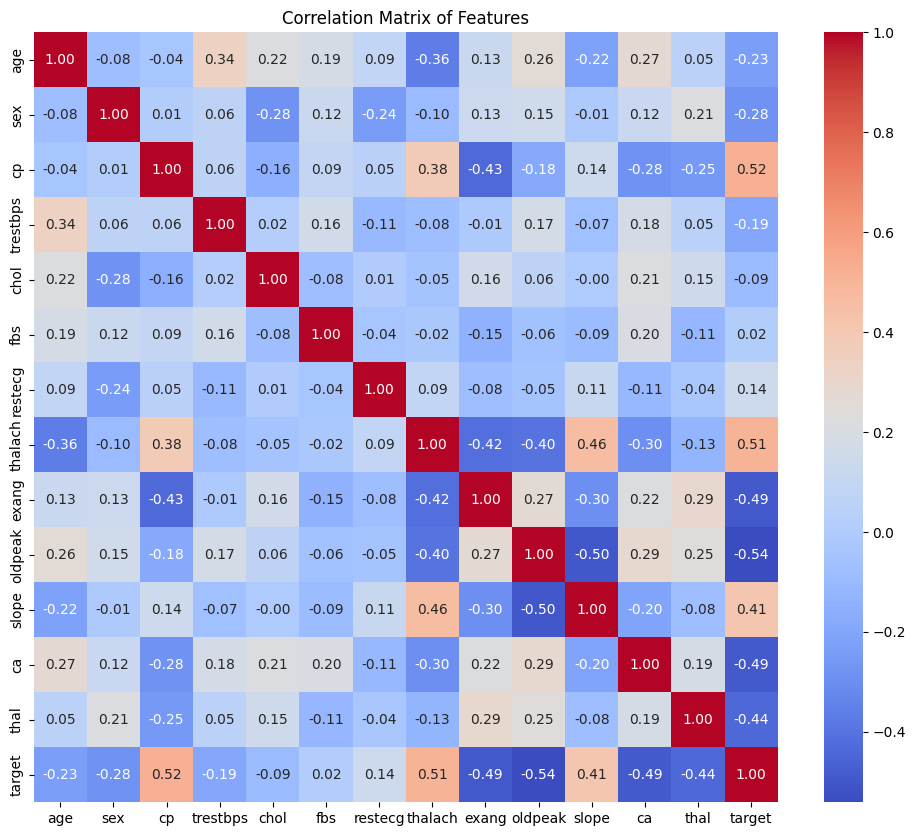


Feature Importance from Logistic Regression Coefficients (absolute magnitude):
     feature  coefficient  abs_coefficient
2         cp     1.475105         1.475105
11        ca    -1.462194         1.462194
9    oldpeak    -1.248597         1.248597
1        sex    -1.135351         1.135351
12      thal    -0.893802         0.893802
7    thalach     0.811373         0.811373
3   trestbps    -0.682829         0.682829
10     slope     0.600024         0.600024
8      exang    -0.533329         0.533329
4       chol    -0.188074         0.188074
5        fbs     0.110782         0.110782
6    restecg     0.073338         0.073338
0        age     0.041477         0.041477


/tmp/ipython-input-1090124624.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='abs_coefficient', y='feature', data=feature_importance, palette='viridis')


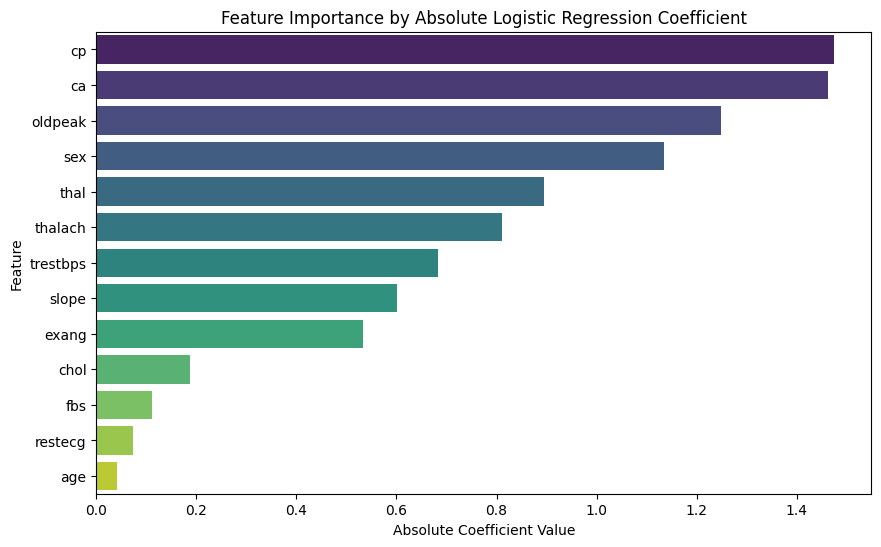

In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop('age_group', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f") # Drop 'age_group' as it's derived
plt.title('Correlation Matrix of Features')
plt.show()

# ogistic regression coefficients
feature_importance = pd.DataFrame({'feature': df.drop(['target', 'age_group'], axis=1).columns, 'coefficient': logmodel.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient']) # absolute values of coefficients
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

print("\nFeature Importance from Logistic Regression Coefficients (absolute magnitude):")
print(feature_importance[['feature', 'coefficient', 'abs_coefficient']])

# Visualize the coefficient values
plt.figure(figsize=(10, 6))
sns.barplot(x='abs_coefficient', y='feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance by Absolute Logistic Regression Coefficient')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

Based on the correlation matrix and the Logistic Regression model's coefficients, we can identify several features that appear to be most important in predicting heart disease in this dataset.

First, `cp` (Chest Pain Type), with the largest positive coefficient (1.48), is the most influential feature. Different types of chest pain are strongly associated with the presence of heart disease. Second, `ca` (number of major vessels), has a large negative coefficient (-1.46). This means that as the number of major vessels increases, the likelihood of heart disease (target = 0) decreases, and vice versa. Also, `oldpeak` (ST Depression induced by exercise) is another significant feature with a negative coefficient (-1.25). Higher oldpeak values (more ST depression) are strongly associated with heart disease. `sex`, with a negative coefficient (-1.14), this indicates that males are more likely to have heart disease than females. Besides, `thal` (Thalassemia) shows a strong negative coefficient (-0.89), suggesting that certain thalassemia types are strongly linked to heart disease.

To conclude, the most important features for predicting heart disease in this dataset are cp (chest pain type), ca (number of major vessels), oldpeak (ST depression), sex, and thal (thalassemia), as these features show the strongest individual influence on the model's prediction of heart disease.

## Assignment 3.2 *(3 points)*: Logistic Regression - CIFAR 10 SMALL dataset

This example demonstrates how to build a logistic regression model to recognize objects in CIFAR 10 dataset.

In this assignment, you will have to:
- 3.2.1 (Done) Load the dataset.
- 3.2.2 *(1 point)* Preprocess and normalize the images.
- 3.2.3 *(1 point)* Construct, train, and evaluate a multinomial logistic regression model for CIFAR 10 SMALL image classification.
- 3.2.4 *(1 point)* Assess the model’s performance on the test set. Keep in mind that low accuracy is acceptable due to the complexity of the data and the limited capacity of logistic regression.

The dataset you will be working on is CIFAR 10 SMALL (https://www.openml.org/d/40926) which consists of 20,000 32x32 colour images in 10 classes, with 2,000 images per class. There are 14,000 training images and 6,000 test images. Here follows the ten object classes:
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

Here follows some data samples in the dataset:

![alt text](https://docs.pytorch.org/tutorials/_images/cifar10.png)

In [ ]:
# Import necessary libraries
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
# Load the CIFAR 10 SMALL dataset from openml
# OpenML is an open platform for sharing datasets, algorithms, and experiments
cifar_10_small = fetch_openml('cifar_10_small', version=1, parser='auto')

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:75: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


In [ ]:
# Separate data into features X and labels y, then convert to numpy arrays
X = cifar_10_small['data'].to_numpy()
y = cifar_10_small['target'].to_numpy()

print("Feature shape: " + str(X.shape))
print("Label shape: " + str(y.shape))

class_names = [
    'airplane',   # Label: 0
    'automobile', # Label: 1
    'bird',       # Label: 2
    'cat',        # Label: 3
    'deer',       # Label: 4
    'dog',        # Label: 5
    'frog',       # Label: 6
    'horse',      # Label: 7
    'ship',       # Label: 8
    'truck'       # Label: 9
]

Feature shape: (20000, 3072)
Label shape: (20000,)


Label: dog


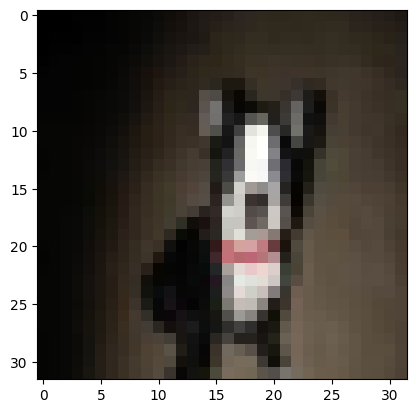

In [ ]:
# Print a sample of the dataset
print("Label: " + class_names[int(y[198])])
plt.imshow(X[198].reshape(3,32,32).transpose([1,2,0])) # The nature of the data requires this restructuring.

Label: automobile


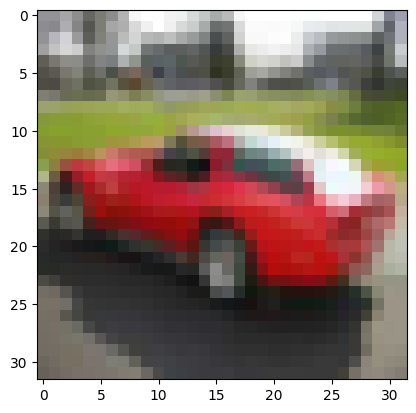

In [ ]:
# Print a sample of the dataset
print("Label: " + class_names[int(y[255])])
plt.imshow(X[255].reshape(3,32,32).transpose([1,2,0])) # The nature of the data requires this restructure.

In [ ]:
# Split the dataset into training and testing sets (using 70% for training and 30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

### 3.2.2 (1 point) Preprocess and normalize the images.

In [ ]:
# Preprocessing: Normalize the data by scaling features to have mean 0 and variance 1
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

### 3.2.3 (1 point) Construct, train, and evaluate a multinomial logistic regression model for CIFAR 10 SMALL image classification.

In [ ]:
# Initialize the Logistic Regression model (use 'saga' solver and multi_class='multinomial')
log_reg = LogisticRegression(multi_class='multinomial', max_iter=120)

# Train the model
log_reg.fit(X_train_norm, y_train)

# Note: To remove the warning, increase the max_iter. However, it takes more time to run the training, and the model is prone to overfitting.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=120, multi_class='multinomial')

In [ ]:
# Make predictions on the test set
y_pred = log_reg.predict(X_test_norm)

### 3.2.4 (1 point) Assess the model’s performance on the test set. Keep in mind that low accuracy is acceptable due to the complexity of the data and the limited capacity of logistic regression.

In [ ]:
# Evaluate the model: Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: " + str(accuracy))

Accuracy on the test set: 0.3435


The accuracy achieved on the test set for this dataset is 34.35%. While this may not be a high value, it is still a meaningful result. To put this into perspective, a random guess without any model would have a probability of only 10%, given that the dataset contains 10 classes. In contrast, applying logistic regression increases the likelihood of a correct prediction to 34.35%, which is more than three times higher than random guessing.

This demonstrates that the model does capture some underlying patterns in the data, despite the complexity of the task. However, the relatively low accuracy suggests that the dataset is highly complex and may require more sophisticated approaches. To achieve better performance, it would be necessary to use more advanced algorithms, such as deep learning models.

Prediction label :airplane


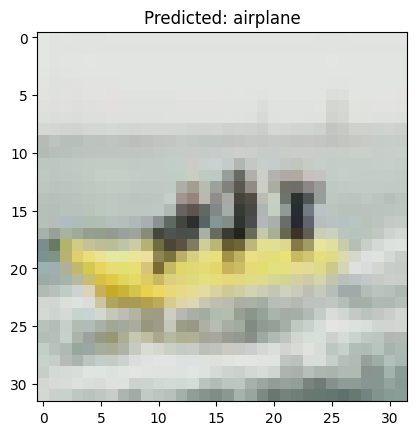

In [ ]:
# Print a test image and its prediction
# Choose an index to display a sample from the CIFAR-10 test set
image_index = 15
print("Prediction label :" + class_names[int(y_pred[image_index])])
plt.imshow(X_test[image_index].reshape(3,32,32).transpose([1,2,0])) # Reshape and transpose for color image display
plt.title("Predicted: " + class_names[int(y_pred[image_index])])
plt.show()

This may not be an airplane, so this time the model made an incorrect guess.

Prediction label :automobile


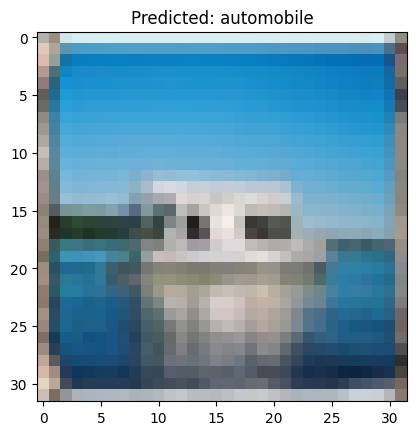

In [ ]:
# Print a test image and its prediction
# Choose an index to display a sample from the CIFAR-10 test set
image_index = 50
print("Prediction label :" + class_names[int(y_pred[image_index])])
plt.imshow(X_test[image_index].reshape(3,32,32).transpose([1,2,0])) # Reshape and transpose for color image display
plt.title("Predicted: " + class_names[int(y_pred[image_index])])
plt.show()

This may be not an automobile, so the model made an incorrect guess.

Prediction label :horse


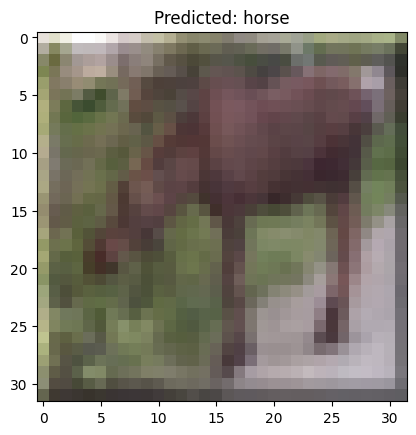

In [ ]:
# Print a test image and its prediction
# Choose an index to display a sample from the CIFAR-10 test set
image_index = 21
print("Prediction label :" + class_names[int(y_pred[image_index])])
plt.imshow(X_test[image_index].reshape(3,32,32).transpose([1,2,0])) # Reshape and transpose for color image display
plt.title("Predicted: " + class_names[int(y_pred[image_index])])
plt.show()

This time, it appears that model made a correct guess.



Prediction label :frog


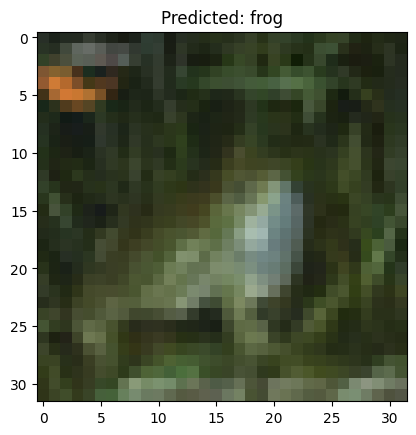

In [ ]:
# Print a test image and its prediction
# Choose an index to display a sample from the CIFAR-10 test set
image_index = 30
print("Prediction label :" + class_names[int(y_pred[image_index])])
plt.imshow(X_test[image_index].reshape(3,32,32).transpose([1,2,0])) # Reshape and transpose for color image display
plt.title("Predicted: " + class_names[int(y_pred[image_index])])
plt.show()

This time, it appears that model made a correct guess.

